<a href="https://colab.research.google.com/github/MeryemBenz/VaR-Analysis/blob/main/VaR_Analysis_2med.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  3 of 3 completed



📊 Portfolio: AAPL, MSFT, GOOG ($1,000,000 initial)
📅 Lookback Period: 756 trading days (~3 years)
🛡️ Confidence Level: 95%

=== Value at Risk (1-day) ===
Historical VaR:    -$26,554 (-2.66%)
Monte Carlo VaR:   -$27,013 (-2.70%)
Parametric VaR:    -$26,760 (-2.68%)


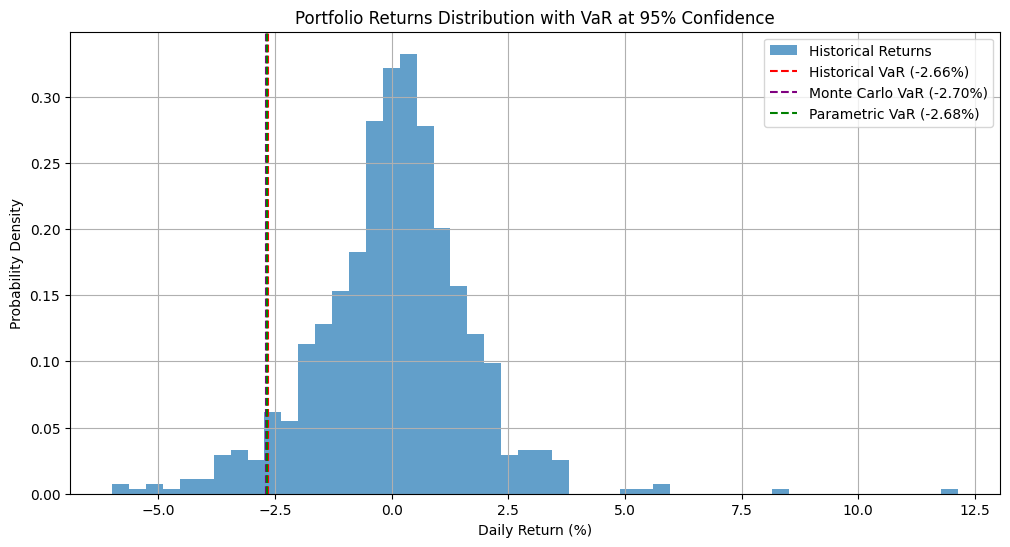


🔥 Potential 40-day Worst-Case Losses:
Historical: -$167,940
Monte Carlo: -$170,844


In [3]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

# ===== USER INPUTS =====
tickers = ["AAPL", "MSFT", "GOOG"]
weights = np.array([0.4, 0.3, 0.3])
initial_investment = 1000000
confidence_level = 0.95
lookback_days = 252 * 3
n_simulations = 10000

# ===== FETCH HISTORICAL DATA =====
def get_portfolio_returns():

    data = yf.download(tickers, period=f"{lookback_days}d", auto_adjust=True)['Close']
    returns = data.pct_change().dropna()
    portfolio_returns = (returns * weights).sum(axis=1)
    return portfolio_returns

portfolio_returns = get_portfolio_returns()

# ===== HISTORICAL VaR =====
def historical_var():
    sorted_returns = np.sort(portfolio_returns)
    var_idx = int((1 - confidence_level) * len(sorted_returns))
    var = sorted_returns[var_idx]
    var_dollar = initial_investment * var
    return var, var_dollar

hist_var, hist_var_dollar = historical_var()

# ===== MONTE CARLO VaR =====
def monte_carlo_var():
    mean_return = portfolio_returns.mean()
    std_dev = portfolio_returns.std()
    simulated_returns = np.random.normal(mean_return, std_dev, n_simulations)
    mc_var = np.percentile(simulated_returns, 100 * (1 - confidence_level))
    mc_var_dollar = initial_investment * mc_var
    return mc_var, mc_var_dollar

mc_var, mc_var_dollar = monte_carlo_var()

# ===== PARAMETRIC VaR =====
def parametric_var():
    mean_return = portfolio_returns.mean()
    std_dev = portfolio_returns.std()
    z_score = norm.ppf(1 - confidence_level)
    param_var = mean_return + z_score * std_dev
    param_var_dollar = initial_investment * param_var
    return param_var, param_var_dollar

param_var, param_var_dollar = parametric_var()

# ===== RESULTS =====
print(f"\n📊 Portfolio: {', '.join(tickers)} (${initial_investment:,.0f} initial)")
print(f"📅 Lookback Period: {lookback_days} trading days (~{lookback_days//252} years)")
print(f"🛡️ Confidence Level: {confidence_level*100:.0f}%")

print("\n=== Value at Risk (1-day) ===")
print(f"Historical VaR:    -${abs(hist_var_dollar):,.0f} ({hist_var*100:.2f}%)")
print(f"Monte Carlo VaR:   -${abs(mc_var_dollar):,.0f} ({mc_var*100:.2f}%)")
print(f"Parametric VaR:    -${abs(param_var_dollar):,.0f} ({param_var*100:.2f}%)")

# ===== VISUALIZATION =====
plt.figure(figsize=(12, 6))


plt.hist(portfolio_returns * 100, bins=50, alpha=0.7,
         density=True, label='Historical Returns')


colors = ['red', 'purple', 'green']
methods = [('Historical', hist_var), ('Monte Carlo', mc_var), ('Parametric', param_var)]
for (method, var), color in zip(methods, colors):
    plt.axvline(x=var * 100, color=color, linestyle='--',
                label=f'{method} VaR ({var*100:.2f}%)')

plt.title(f"Portfolio Returns Distribution with VaR at {confidence_level*100:.0f}% Confidence")
plt.xlabel("Daily Return (%)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

# ===== WORST-CASE SCENARIOS =====
n_days = 30
print(f"\n🔥 Potential {n_days}-day Worst-Case Losses:")
print(f"Historical: -${abs(initial_investment * hist_var * np.sqrt(n_days)):,.0f}")
print(f"Monte Carlo: -${abs(initial_investment * mc_var * np.sqrt(n_days)):,.0f}")